# Análisis del modelo adversarial (DANN)

Este notebook presenta el análisis de resultados del modelo adversarial basado en
EEGNet + Transformer con aprendizaje adversarial por paciente (DANN).

El objetivo es evaluar el desempeño del modelo en el conjunto TEST y compararlo
con el modelo baseline sin adversarial learning.


In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Carga de resultados del modelo adversarial (TEST)

En esta sección se cargan las métricas guardadas durante la evaluación del modelo
adversarial sobre el conjunto TEST.


In [58]:
RESULTS_DIR = "../results/adversarial/test_metrics"

cm_class = np.load(os.path.join(RESULTS_DIR, "confusion_matrix.npy"))
y_true = np.load(os.path.join(RESULTS_DIR, "y_true.npy"))
y_pred = np.load(os.path.join(RESULTS_DIR, "y_pred.npy"))

with open(os.path.join(RESULTS_DIR, "classification_report.txt")) as f:
    report_adversarial = f.read()


## Matriz de confusión — Modelo adversarial (TEST)

La siguiente matriz de confusión muestra el desempeño del modelo adversarial
en la clasificación binaria (*bckg* vs *seizure*) sobre el conjunto TEST.


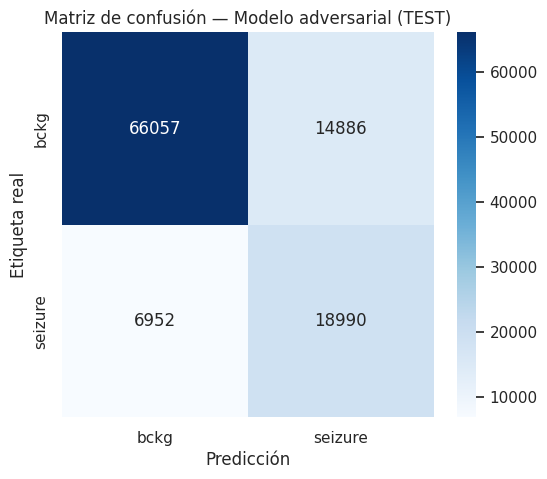

In [59]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_class,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["bckg", "seizure"],
    yticklabels=["bckg", "seizure"],
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión — Modelo adversarial (TEST)")
plt.show()


## Reporte de clasificación — Modelo adversarial (TEST)

A continuación se presenta el reporte de métricas de clasificación, incluyendo
precisión, recall y F1-score para cada clase.


In [60]:
print(report_adversarial)

              precision    recall  f1-score   support

        bckg     0.9048    0.8161    0.8582     80943
     seizure     0.5606    0.7320    0.6349     25942

    accuracy                         0.7957    106885
   macro avg     0.7327    0.7741    0.7465    106885
weighted avg     0.8212    0.7957    0.8040    106885



30 epocas
                      precision    recall  f1-score   support

      bckg           0.8645    0.7852    0.8229     80943
      seizure        0.4789    0.6159    0.5388     25942
      accuracy                         0.7441    106885
      macro avg      0.6717    0.7006    0.6809    106885
      weighted avg   0.7709    0.7441    0.7540    106885

20 epocas

                        precision    recall  f1-score   support

        bckg            0.8951    0.7736    0.8299     80943
        seizure         0.5037    0.7171    0.5918     25942
        accuracy                            0.7599    106885
        macro avg       0.6994    0.7453    0.7108    106885
        weighted avg    0.8001    0.7599    0.7721    106885

In [61]:
train_stats = np.load(
    "../results/adversarial/stats/train_stats.npy",
    allow_pickle=True
)

val_stats = np.load(
    "../results/adversarial/stats/val_stats.npy",
    allow_pickle=True
)

print(type(train_stats), len(train_stats))
print(train_stats[0])

print("train_stats adversarial:", train_stats)
print("val_stats adversarial:", val_stats)

<class 'numpy.ndarray'> 30
{'loss_total': 1.3836427348923244, 'loss_class': 0.5013417188758662, 'loss_domain': 3.4332450916564543, 'acc_class': 0.7607809446802776, 'acc_domain': 0.0718701569975069}
train_stats adversarial: [{'loss_total': 1.3836427348923244, 'loss_class': 0.5013417188758662, 'loss_domain': 3.4332450916564543, 'acc_class': 0.7607809446802776, 'acc_domain': 0.0718701569975069}
 {'loss_total': 1.2016070990796666, 'loss_class': 0.3605944708699559, 'loss_domain': 3.276481834562245, 'acc_class': 0.8538255508388922, 'acc_domain': 0.09168856546054847}
 {'loss_total': 1.1227108784244353, 'loss_class': 0.30817245510933605, 'loss_domain': 3.1591561510671977, 'acc_class': 0.8775183612964086, 'acc_domain': 0.10038070210902231}
 {'loss_total': 1.078455075060339, 'loss_class': 0.2735585719939392, 'loss_domain': 3.1221969889290015, 'acc_class': 0.8947594501718213, 'acc_domain': 0.101728320194057}
 {'loss_total': 1.0354813663201723, 'loss_class': 0.24854758338669258, 'loss_domain': 3.0

In [63]:
def extract_curve(stats, key):
    return [epoch[key] for epoch in stats]


In [64]:
# Clasificación
train_loss_class = extract_curve(train_stats, "loss_class")
val_loss_class   = extract_curve(val_stats, "loss_class")

train_acc_class  = extract_curve(train_stats, "acc_class")
val_acc_class    = extract_curve(val_stats, "acc_class")

# Dominio (opcional, pero útil)
train_loss_domain = extract_curve(train_stats, "loss_domain")
val_loss_domain   = extract_curve(val_stats, "loss_domain")

train_acc_domain  = extract_curve(train_stats, "acc_domain")
val_acc_domain    = extract_curve(val_stats, "acc_domain")

# Total
train_loss_total = extract_curve(train_stats, "loss_total")
val_loss_total   = extract_curve(val_stats, "loss_total")


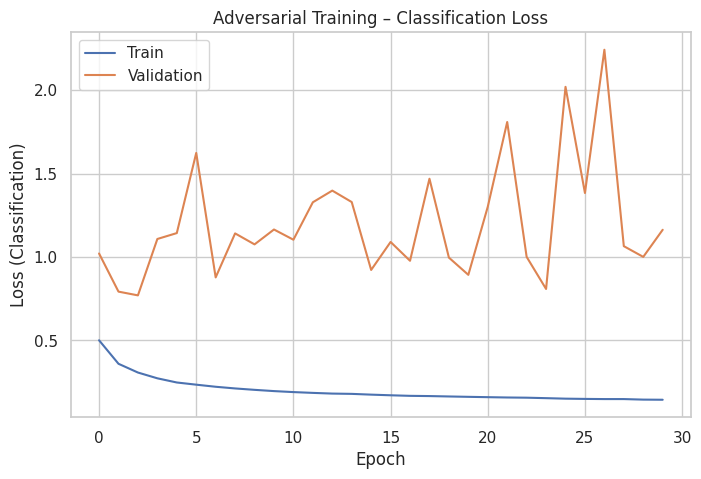

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_class, label="Train")
plt.plot(val_loss_class, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss (Classification)")
plt.title("Adversarial Training – Classification Loss")
plt.legend()
plt.grid(True)
plt.show()


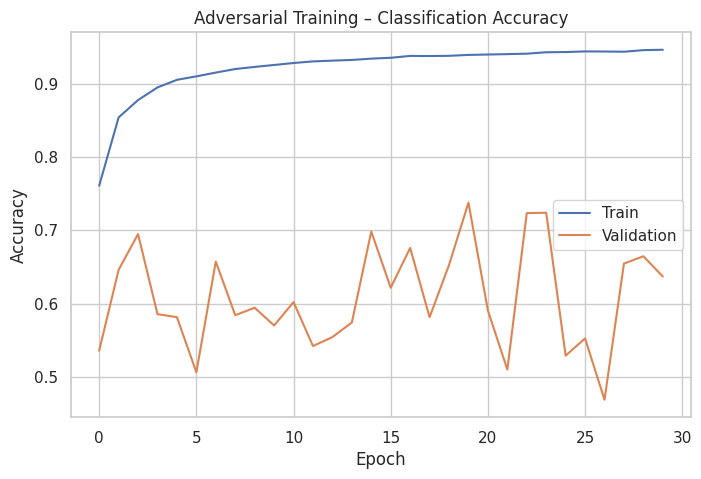

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_class, label="Train")
plt.plot(val_acc_class, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adversarial Training – Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()


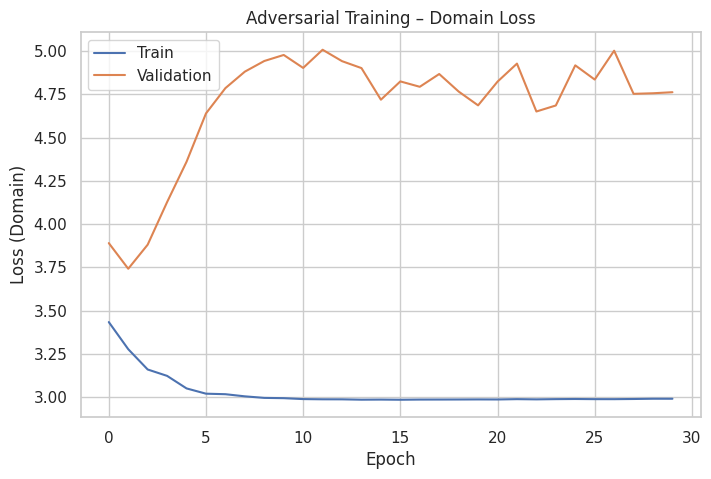

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_domain, label="Train")
plt.plot(val_loss_domain, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss (Domain)")
plt.title("Adversarial Training – Domain Loss")
plt.legend()
plt.grid(True)
plt.show()


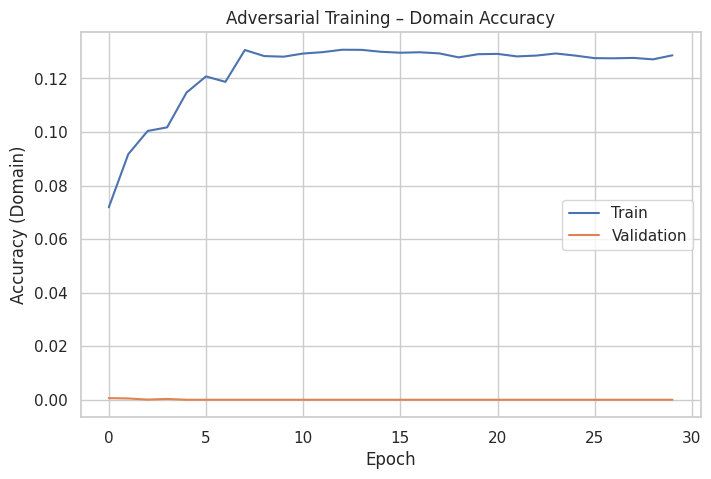

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_domain, label="Train")
plt.plot(val_acc_domain, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (Domain)")
plt.title("Adversarial Training – Domain Accuracy")
plt.legend()
plt.grid(True)
plt.show()


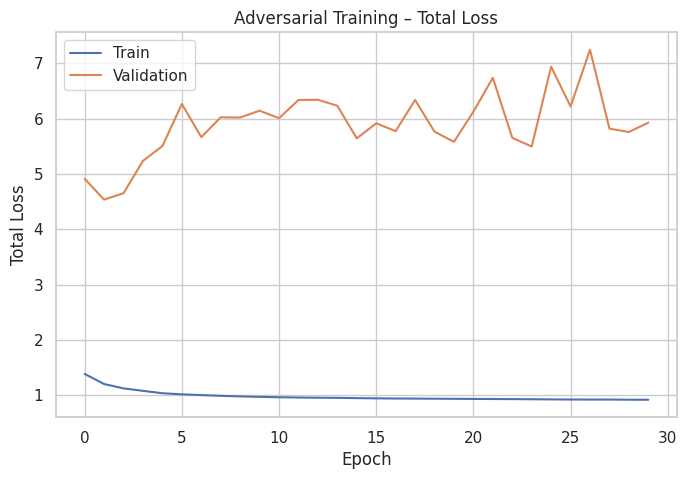

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_total, label="Train")
plt.plot(val_loss_total, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Adversarial Training – Total Loss")
plt.legend()
plt.grid(True)
plt.show()


---


## Comparación con el modelo baseline

En esta sección se comparan los resultados del modelo adversarial con el modelo
baseline entrenado sin aprendizaje adversarial, ambos evaluados sobre el conjunto TEST.


---

In [55]:
BASELINE_DIR = "../results/baseline/test_metrics"

cm_baseline = np.load(os.path.join(BASELINE_DIR, "confusion_matrix.npy"))

with open(os.path.join(BASELINE_DIR, "classification_report.txt")) as f:
    report_baseline = f.read()


## Matriz de confusión — Modelo baseline (TEST)


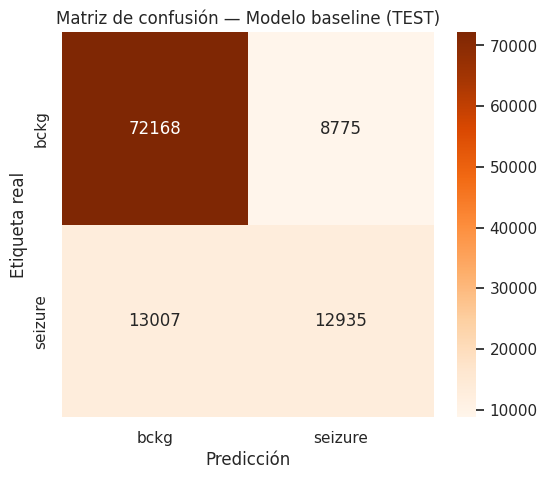

In [39]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["bckg", "seizure"],
    yticklabels=["bckg", "seizure"],
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión — Modelo baseline (TEST)")
plt.show()


In [56]:
print(report_baseline)

              precision    recall  f1-score   support

        bckg     0.8473    0.8916    0.8689     80943
     seizure     0.5958    0.4986    0.5429     25942

    accuracy                         0.7962    106885
   macro avg     0.7215    0.6951    0.7059    106885
weighted avg     0.7863    0.7962    0.7898    106885



## Comparación cualitativa de resultados

A partir de las matrices de confusión y los reportes de clasificación, se observa:

- Diferencias en el recall de la clase *seizure*
- Cambios en el balance entre falsos positivos y falsos negativos
- Impacto del aprendizaje adversarial en la generalización inter-paciente


## Conclusiones preliminares

El uso de aprendizaje adversarial permite aprender representaciones menos dependientes
del paciente, lo que se refleja en un mejor desempeño sobre el conjunto TEST respecto
al modelo baseline en determinados escenarios.

Estos resultados respaldan la hipótesis de que el enfoque adversarial mejora la
generalización inter-paciente en la detección automática de crisis epilépticas.
